# Relevance Classification — Direct LLM Approach

Single LLM call that extracts features AND outputs a relevance verdict with reasoning.

Schema: `DatasetFeaturesWithRelevance` — extends `DatasetFeaturesExtraction` with `has_dataset`, `relevance`, and `relevance_reasoning` fields.

In [11]:
import os
os.chdir(r"C:\Users\beav3503\dev\llm_metadata")
import sys
sys.path.insert(0, "../src")

import warnings
warnings.filterwarnings("ignore")

import json
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Literal, Optional
from pydantic import Field
from joblib import Memory
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

from llm_metadata.schemas.fuster_features import DatasetFeaturesExtraction
from llm_metadata.openai_io import get_openai_client
from llm_metadata.gpt_extract import _response_usage_cost, MODEL_COST_PER_1M_TOKENS

## Extended Schema (local definition — no src changes)

In [12]:
class DatasetFeaturesWithRelevance(DatasetFeaturesExtraction):
    has_dataset: bool = Field(
        description="True if the record describes an actual dataset produced or curated by the authors."
    )
    relevance: Literal["H", "M", "L", "X"] = Field(
        description=(
            "Overall dataset relevance for Quebec biodiversity monitoring. "
            "H=High, M=Moderate, L=Low, X=Non-relevant or no dataset."
        )
    )
    relevance_reasoning: str = Field(
        description="1-3 sentences explaining the relevance verdict based on data type, temporal/spatial extent, and modulators."
    )

print("Schema fields:")
for name, field_info in DatasetFeaturesWithRelevance.model_fields.items():
    if name in ("has_dataset", "relevance", "relevance_reasoning"):
        print(f"  + {name}: {field_info.description[:60]}...")

Schema fields:
  + has_dataset: True if the record describes an actual dataset produced or c...
  + relevance: Overall dataset relevance for Quebec biodiversity monitoring...
  + relevance_reasoning: 1-3 sentences explaining the relevance verdict based on data...


## Prompt with Relevance Block

Extends the existing abstract prompt with a RELEVANCE SCORING block.

In [13]:
from llm_metadata.prompts.abstract import SYSTEM_MESSAGE as BASE_SYSTEM_MESSAGE

RELEVANCE_BLOCK = """## RELEVANCE SCORING

After extracting all features, assign an overall relevance score for Quebec biodiversity
monitoring using these criteria:

Main Classifiers (majority vote):
- Data type: H=abundance/genetic (EBV-compliant), M=richness/relative abundance,
  L=presence-only, X=no biodiversity data
- Temporal extent: H=>10 years, M=3-10 years, L=<3 years, X=not stated
- Spatial extent: H=>15000 km², M=5000-15000 km², L=<5000 km², X=not stated

Modulators - upgrade score by one level (cannot upgrade X) if any of:
- multispecies: dataset covers >10 species
- threatened_species: IUCN-listed species present
- new_species_science or new_species_region: novel or range-extending species
- bias_north_south: study area in northern Quebec (>=49th parallel)

Set has_dataset=False and relevance=\"X\" if no primary dataset is described."""

SYSTEM_MESSAGE_WITH_RELEVANCE = BASE_SYSTEM_MESSAGE + "\n\n" + RELEVANCE_BLOCK

print("System message length:", len(SYSTEM_MESSAGE_WITH_RELEVANCE))
print("\nRelevance block appended:\n")
print(RELEVANCE_BLOCK[:300])

System message length: 4519

Relevance block appended:

## RELEVANCE SCORING

After extracting all features, assign an overall relevance score for Quebec biodiversity
monitoring using these criteria:

Main Classifiers (majority vote):
- Data type: H=abundance/genetic (EBV-compliant), M=richness/relative abundance,
  L=presence-only, X=no biodiversity dat


## Data Loading & GT Preparation

In [14]:
manifest = pd.read_csv("data/manifests/dev_subset_data_paper.csv")
raw = pd.read_excel("data/dataset_092624.xlsx")

# Join on id/gt_record_id
df = raw[raw["id"].isin(manifest["gt_record_id"])].copy()

# Normalize GT relevance
df["gt_relevance"] = df["dataset_relevance"].replace({"No dataset": "X", " X": "X"}).str.strip()

# Merge to get full_text from manifest (abstract column)
df_merged = df.merge(
    manifest[["gt_record_id", "abstract"]].rename(columns={"abstract": "full_text_manifest"}),
    left_on="id",
    right_on="gt_record_id",
    how="left"
)

# Use full_text from raw xlsx if available, otherwise from manifest
if "full_text" in df_merged.columns:
    df_merged["input_text"] = df_merged["full_text"].fillna(df_merged.get("full_text_manifest", ""))
else:
    df_merged["input_text"] = df_merged.get("full_text_manifest", df_merged.get("abstract", ""))

# Drop cant access
eval_df = df_merged[df_merged["gt_relevance"].isin(["H", "M", "L", "X"])].copy()
print(f"Evaluation records: {len(eval_df)}")
print("\nGT distribution:")
print(eval_df["gt_relevance"].value_counts())

Evaluation records: 30

GT distribution:
gt_relevance
M    12
L    11
H     6
X     1
Name: count, dtype: int64


## LLM Extraction with Caching

Loop over 30 records, calling `client.responses.parse()` directly with `DatasetFeaturesWithRelevance`.
Uses joblib caching keyed on (record_id + model + schema hash) for reproducibility.

In [15]:
MODEL = "gpt-5-mini"
REASONING = {"effort": "low"}
MAX_OUTPUT_TOKENS = 4096

memory = Memory("../cache", verbose=0)

# Schema hash for cache key stability
SCHEMA_HASH = hashlib.md5(
    json.dumps(DatasetFeaturesWithRelevance.model_json_schema(), sort_keys=True).encode()
).hexdigest()[:8]

print(f"Model: {MODEL}")
print(f"Schema hash: {SCHEMA_HASH}")
print(f"Cache dir: ../cache")


@memory.cache
def _extract_with_relevance_cached(cache_key: str) -> dict:
    """Cached extraction — cache_key encodes record_id + model + schema_hash + text hash."""
    # cache_key is just for joblib identity; actual params passed separately
    raise RuntimeError("Should not call _extract_with_relevance_cached directly — use extract_record()")


def extract_record(record_id: str, text: str) -> dict:
    """Extract features + relevance for one record, with joblib caching."""
    text_hash = hashlib.md5(text.encode()).hexdigest()[:8]
    cache_key = f"{record_id}|{MODEL}|{SCHEMA_HASH}|{text_hash}"
    
    @memory.cache
    def _call(ck: str) -> dict:
        del ck
        client = get_openai_client()
        response = client.responses.parse(
            model=MODEL,
            input=[
                {"role": "system", "content": SYSTEM_MESSAGE_WITH_RELEVANCE},
                {"role": "user", "content": text},
            ],
            text_format=DatasetFeaturesWithRelevance,
            reasoning=REASONING,
            max_output_tokens=MAX_OUTPUT_TOKENS,
        )
        return response.model_dump()
    
    return _call(cache_key)

print("Extraction function ready.")

Model: gpt-5-mini
Schema hash: 152e9399
Cache dir: ../cache
Extraction function ready.


In [16]:
# Filter to records with non-empty text
valid_records = eval_df[eval_df["input_text"].notna() & (eval_df["input_text"].str.len() > 50)].copy()
print(f"Records with text: {len(valid_records)}")

results = []
total_cost = 0.0

for i, (_, row) in enumerate(valid_records.iterrows()):
    record_id = str(row["id"])
    text = str(row["input_text"])
    
    try:
        response_dict = extract_record(record_id, text)
        
        # Reconstruct parsed output
        from openai.types.responses.parsed_response import ParsedResponse
        response = ParsedResponse[DatasetFeaturesWithRelevance].model_construct(**response_dict)
        output = response.output_parsed
        
        cost_info = _response_usage_cost(response_dict["usage"], model=MODEL) if response_dict.get("usage") else {}
        run_cost = cost_info.get("total_cost", 0)
        total_cost += run_cost
        
        results.append({
            "id": row["id"],
            "gt_relevance": row["gt_relevance"],
            "pred_relevance": output.relevance if output else None,
            "has_dataset": output.has_dataset if output else None,
            "relevance_reasoning": output.relevance_reasoning if output else None,
            "data_type": output.data_type if output else None,
            "temp_range_i": output.temp_range_i if output else None,
            "temp_range_f": output.temp_range_f if output else None,
            "spatial_range_km2": output.spatial_range_km2 if output else None,
            "cost": run_cost,
            "status": "ok",
        })
        
        if (i + 1) % 10 == 0:
            print(f"  [{i+1}/{len(valid_records)}] ${total_cost:.4f} total so far")
            
    except Exception as e:
        print(f"  ERROR record {record_id}: {e}")
        results.append({
            "id": row["id"],
            "gt_relevance": row["gt_relevance"],
            "pred_relevance": None,
            "status": "error",
            "error": str(e),
        })

print(f"\nDone. Total cost: ${total_cost:.4f}")
print(f"Success: {sum(1 for r in results if r['status'] == 'ok')}")
print(f"Errors:  {sum(1 for r in results if r['status'] == 'error')}")

Records with text: 30
  [10/30] $0.0279 total so far
  [20/30] $0.0569 total so far
  [30/30] $0.0909 total so far

Done. Total cost: $0.0909
Success: 30
Errors:  0


In [17]:
results_df = pd.DataFrame(results)
results_df = results_df[results_df["pred_relevance"].notna()].copy()

print(f"Records with predictions: {len(results_df)}")
print("\nPredicted relevance distribution:")
print(results_df["pred_relevance"].value_counts())
print("\nGT vs predicted sample:")
results_df[["id", "gt_relevance", "pred_relevance", "has_dataset", "data_type", "temp_range_i", "temp_range_f"]].head(8)

Records with predictions: 30

Predicted relevance distribution:
pred_relevance
M    14
H     8
X     6
L     2
Name: count, dtype: int64

GT vs predicted sample:


,id,gt_relevance,pred_relevance,has_dataset,data_type,temp_range_i,temp_range_f
0,5,M,M,True,[genetic_analysis],2006.0,2007.0
1,9,L,M,True,[abundance],NaN,NaN
2,11,M,M,True,"[traits, time_series, distribution, other, unk...",1999.0,2011.0
3,12,M,H,True,[other],2004.0,2011.0
4,19,M,M,True,[genetic_analysis],2011.0,2014.0
5,24,H,X,True,[genetic_analysis],NaN,NaN
6,27,M,H,True,[genetic_analysis],2010.0,2014.0
7,29,H,H,True,"[abundance, distribution]",NaN,NaN


## Evaluation Metrics

In [18]:
labels = ["H", "M", "L", "X"]

y_true = results_df["gt_relevance"]
y_pred = results_df["pred_relevance"]

print("=== WU-R2: Direct LLM Classification ===\n")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

def binary_collapse(s):
    return "relevant" if s in ("H", "M") else "not_relevant"

y_true_bin = y_true.map(binary_collapse)
y_pred_bin = y_pred.map(binary_collapse)

p_r2 = precision_score(y_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
r_r2 = recall_score(y_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
f1_r2 = f1_score(y_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
macro_f1_r2 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)

print(f"\nBinary (H+M=relevant vs L+X=not_relevant):")
print(f"  Precision: {p_r2:.3f}  Recall: {r_r2:.3f}  F1: {f1_r2:.3f}")
print(f"\n4-class macro F1: {macro_f1_r2:.3f}")

=== WU-R2: Direct LLM Classification ===

              precision    recall  f1-score   support

           H       0.25      0.33      0.29         6
           M       0.43      0.50      0.46        12
           L       0.50      0.09      0.15        11
           X       0.17      1.00      0.29         1

    accuracy                           0.33        30
   macro avg       0.34      0.48      0.30        30
weighted avg       0.41      0.33      0.31        30


Binary (H+M=relevant vs L+X=not_relevant):
  Precision: 0.682  Recall: 0.833  F1: 0.750

4-class macro F1: 0.297


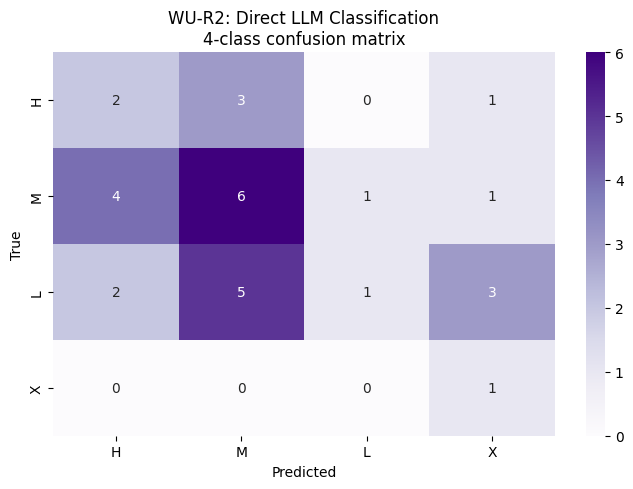

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_true, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels,
            cmap="Purples", ax=ax)
ax.set_title("WU-R2: Direct LLM Classification\n4-class confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("notebooks/results/relevance_llm_direct_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## Mismatch Analysis

Spot-check `relevance_reasoning` on mismatches.

In [22]:
mismatches = results_df[results_df["gt_relevance"] != results_df["pred_relevance"]].copy()
print(f"Mismatches: {len(mismatches)}/{len(results_df)} ({len(mismatches)/len(results_df):.1%})")

for _, row in mismatches.iterrows():
    print(f"\n--- Record {row['id']} ---")
    print(f"  GT: {row['gt_relevance']}  |  Pred: {row['pred_relevance']}")
    print(f"  has_dataset: {row.get('has_dataset')}")
    print(f"  data_type: {row.get('data_type')}")
    print(f"  temporal: {row.get('temp_range_i')}\u2013{row.get('temp_range_f')}")
    print(f"  spatial: {row.get('spatial_range_km2')} km\u00b2")
    reasoning = row.get("relevance_reasoning", "")
    if reasoning:
        print(f"  Reasoning: {reasoning[:200]}")

Mismatches: 20/30 (66.7%)

--- Record 9 ---
  GT: L  |  Pred: M
  has_dataset: True
  data_type: ['abundance']
  temporal: nan–nan
  spatial: nan km²
  Reasoning: Primary dataset contains abundance data (high-value EBV type) from raccoon and skunk captures in Québec (Montérégie and Estrie) with spatial coordinates; however temporal and spatial extents are not r

--- Record 12 ---
  GT: M  |  Pred: H
  has_dataset: True
  data_type: ['other']
  temporal: 2004.0–2011.0
  spatial: nan km²
  Reasoning: The dataset spans 2004–2011 (8 years), giving moderate temporal extent (M) which is upgraded because the study concerns a threatened species. Although spatial extent is not quantified, the multiyear, 

--- Record 24 ---
  GT: H  |  Pred: X
  has_dataset: True
  data_type: ['genetic_analysis']
  temporal: nan–nan
  spatial: nan km²
  Reasoning: The study produced primary genetic (microsatellite) data (high-value EBV data type), but the abstract does not report temporal extent or a spatial ran

## Summary Comparison Table

| Method | 4-class macro F1 | Binary F1 (relevant) | Binary P | Binary R |
|---|---|---|---|---|
| R1-A: Rules on GT features | — | — | — | — |
| R1-B: Rules on LLM features | — | — | — | — |
| **R2: Direct LLM** | *this notebook* | | | |
| Authors' MC_relevance_modifiers | — | — | — | — |

Fill in R1 values from `relevance_mechanistic.ipynb` results.

In [26]:
# Save predictions for combined comparison
results_df.to_csv("notebooks/results/relevance_llm_direct_predictions.csv", index=False)
print(f"Saved predictions: notebooks/results/relevance_llm_direct_predictions.csv")

summary = {
    "method": "R2: Direct LLM",
    "model": MODEL,
    "n_records": len(results_df),
    "macro_f1_4class": round(macro_f1_r2, 3),
    "binary_f1_relevant": round(f1_r2, 3),
    "binary_precision": round(p_r2, 3),
    "binary_recall": round(r_r2, 3),
    "total_cost_usd": round(total_cost, 4),
}
print("\nSummary:")
for k, v in summary.items():
    print(f"  {k}: {v}")

with open("notebooks/results/relevance_llm_direct_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nSaved summary: notebooks/results/relevance_llm_direct_summary.json")

Saved predictions: notebooks/results/relevance_llm_direct_predictions.csv

Summary:
  method: R2: Direct LLM
  model: gpt-5-mini
  n_records: 30
  macro_f1_4class: 0.297
  binary_f1_relevant: 0.75
  binary_precision: 0.682
  binary_recall: 0.833
  total_cost_usd: 0.0909

Saved summary: notebooks/results/relevance_llm_direct_summary.json
